In [1]:
import pandas as pd
print("pandas working")

pandas working


In [ ]:
df= pd.read_csv("../data/raw/student_lifestyle.csv")
df.head()

TypeError: 'tuple' object is not callable

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [6]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

In [7]:
df["Stress_Level"].value_counts()

Stress_Level
5     24525
4     23326
3     22666
2     13591
6     11653
7      2255
8      1506
9       474
10        4
Name: count, dtype: int64

In [8]:
df["burnout"] = (df["Stress_Level"] >= 6).astype(int)

df["burnout"].value_counts(normalize=True)

burnout
0    0.84108
1    0.15892
Name: proportion, dtype: float64

Matplotlib is building the font cache; this may take a moment.


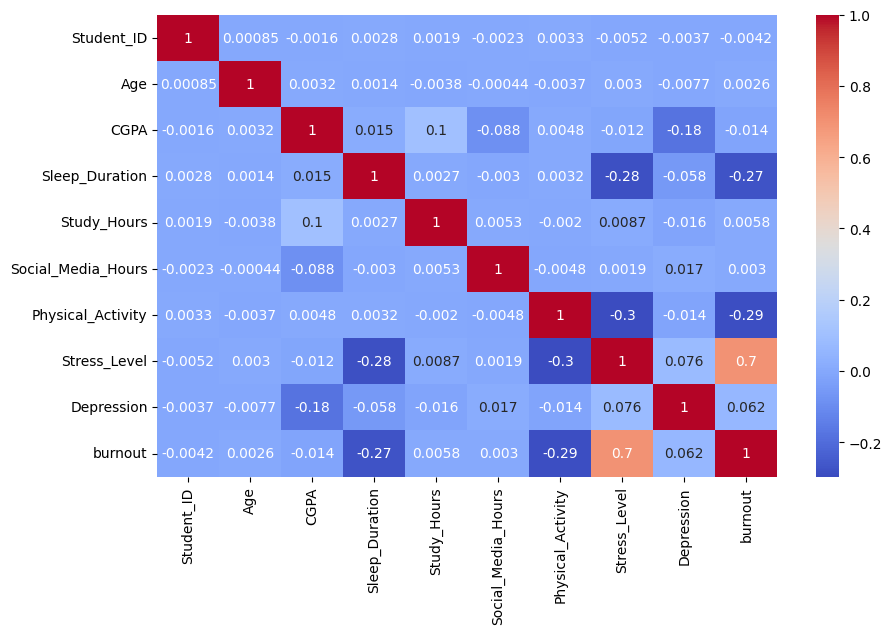

In [9]:
corr = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [10]:
correlations_with_burnout = corr["burnout"].sort_values(ascending=False)
print(correlations_with_burnout)

burnout               1.000000
Stress_Level          0.699036
Depression            0.062460
Study_Hours           0.005789
Social_Media_Hours    0.002988
Age                   0.002595
Student_ID           -0.004163
CGPA                 -0.014033
Sleep_Duration       -0.273472
Physical_Activity    -0.290443
Name: burnout, dtype: float64


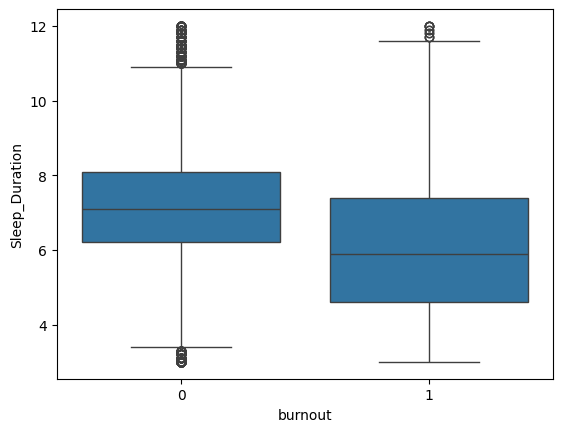

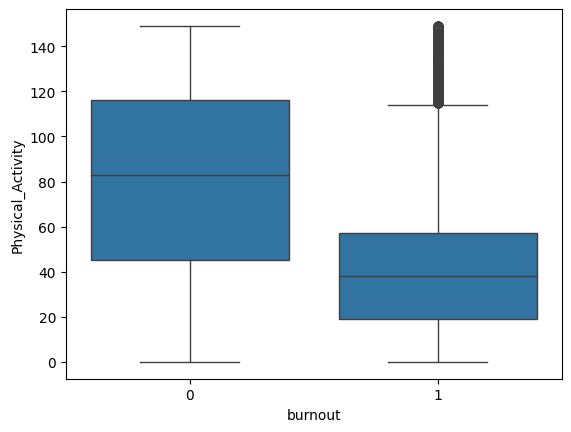

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="burnout", y="Sleep_Duration", data=df)
plt.show()
sns.boxplot(x="burnout", y="Physical_Activity", data=df)
plt.show()